<a href="https://colab.research.google.com/github/Carereen/image-processing/blob/main/Lab7_Sec2_6853800122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys

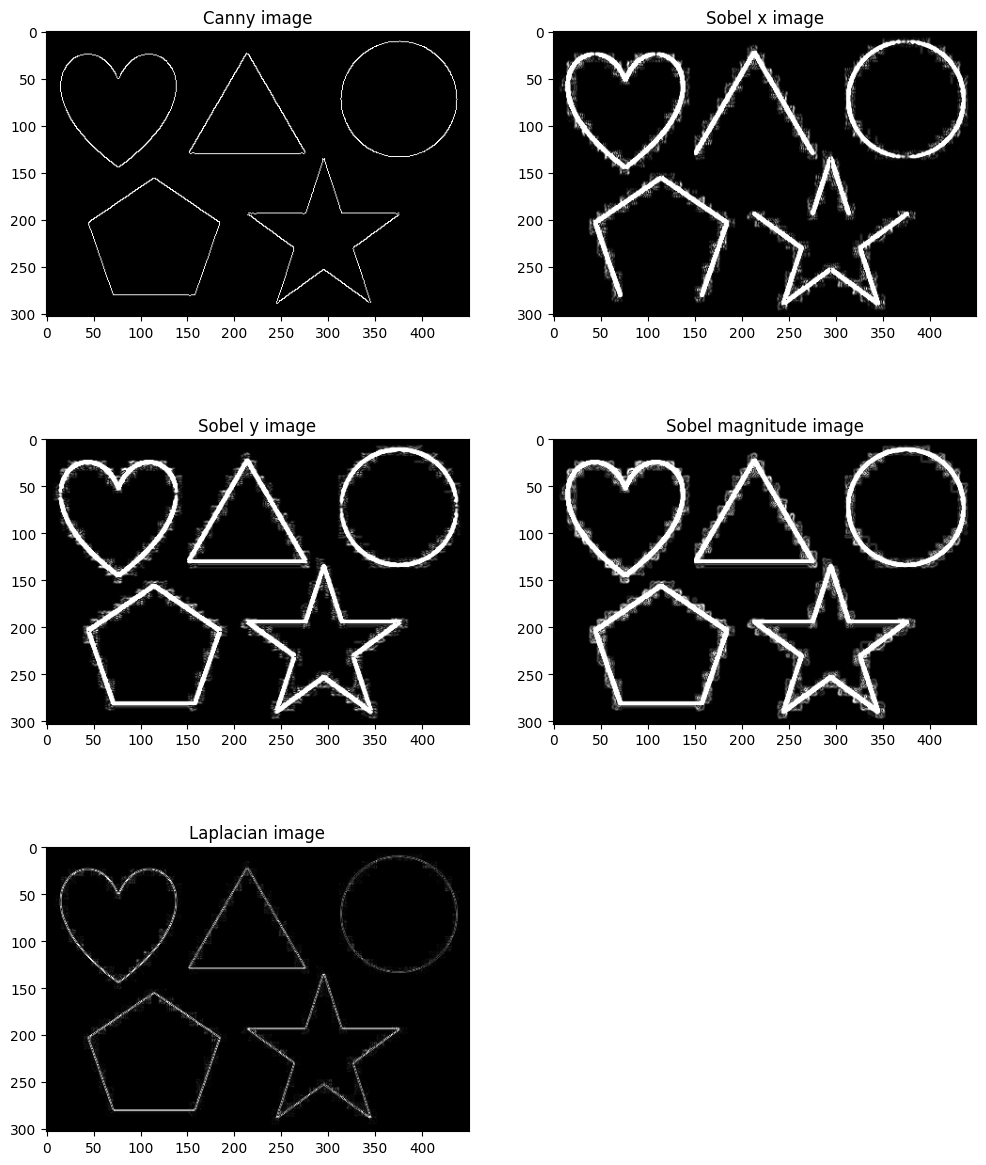

In [ ]:
path = '/content/drive/MyDrive/2568-term2/image/week 7/'
image_name = 'all_shape.jpg'
image_gray = cv2.imread(path + image_name, 0)

if image_gray is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

# canny = จับขอบภาพ
image_canny = cv2.Canny(image_gray, 100, 255)

sobelx = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize = 5)
image_sobelx = cv2.convertScaleAbs(sobelx)

sobely = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize = 5)
image_sobely = cv2.convertScaleAbs(sobely)

# combining S and Y directions
mag = cv2.magnitude(sobelx, sobely)
image_sobel_mag = cv2.convertScaleAbs(mag)

# laplacian = เจอขอบทุกทิศทาง noise เยอะ -> ใช้ตรวจจับภาพ second derivative(ภาพที่ผ่านการดัดแปลงมาแล้ว)
laplacian = cv2.Laplacian(image_gray, cv2.CV_64F)
image_laplacian = cv2.convertScaleAbs(laplacian)

plt.figure(figsize = (12, 15))
plt.subplot(3, 2, 1)
plt.imshow(image_canny, cmap = 'gray')
plt.title('Canny image')

plt.subplot(3, 2, 2)
plt.imshow(image_sobelx, cmap = 'gray')
plt.title('Sobel x image')

plt.subplot(3, 2, 3)
plt.imshow(image_sobely, cmap = 'gray')
plt.title('Sobel y image')

plt.subplot(3, 2, 4)
plt.imshow(image_sobel_mag, cmap = 'gray')
plt.title('Sobel magnitude image')

plt.subplot(3, 2, 5)
plt.imshow(image_laplacian, cmap = 'gray')
plt.title('Laplacian image')
plt.show()

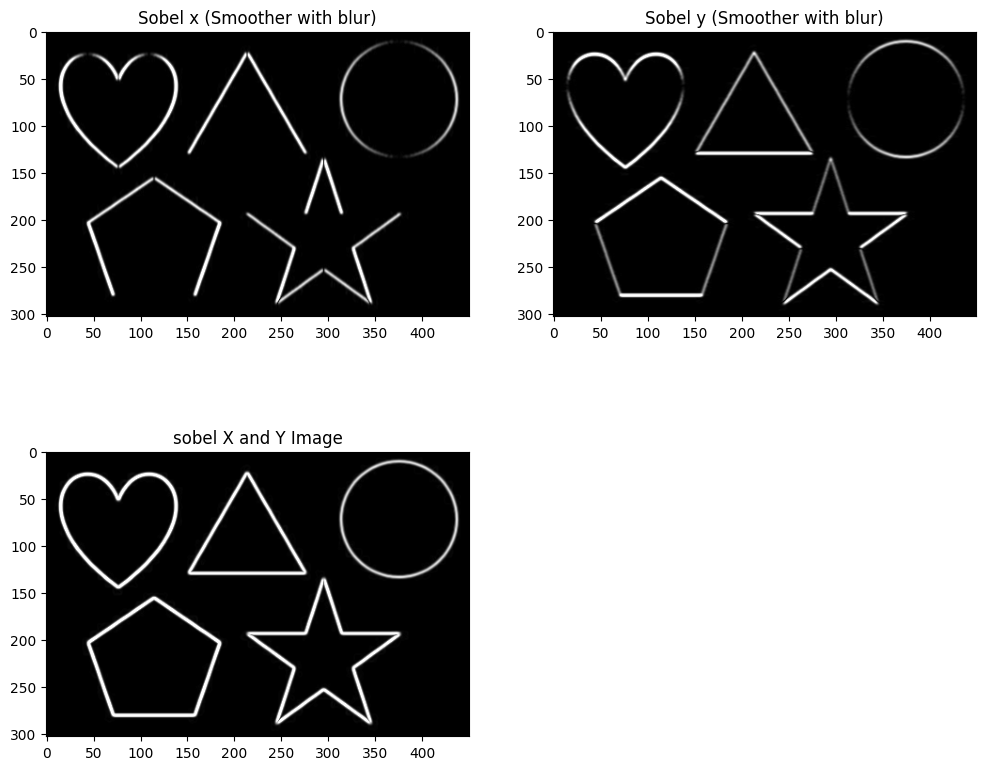

In [ ]:
path = '/content/drive/MyDrive/2568-term2/image/week 7/'
image_name = 'all_shape.jpg'
image_gray = cv2.imread(path + image_name, 0)

if image_gray is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

# compute x use 1, 0
sobelx_blur = cv2.Sobel(image_blurred, cv2.CV_64F, 1, 0, ksize = 3)
image_sobelx_blur = cv2.convertScaleAbs(sobelx_blur)

# compute y use 0, 1
sobely_blur = cv2.Sobel(image_blurred, cv2.CV_64F, 0, 1, ksize = 3)
image_sobely_blur = cv2.convertScaleAbs(sobely_blur)

# converScaleAbs = ผลจาก sobel มีค่าติดลบ, เป็น float -> แสดงเป็นภาพไม่ได้
mag = cv2.magnitude(sobelx_blur, sobely_blur)
image_sobel_mag_blur = cv2.convertScaleAbs(mag)

plt.figure(figsize = (12, 10))
plt.subplot(2, 2, 1)
plt.imshow(image_sobelx_blur, cmap = 'gray')
plt.title('Sobel x (Smoother with blur)')

plt.subplot(2, 2, 2)
plt.imshow(image_sobely_blur, cmap = 'gray')
plt.title('Sobel y (Smoother with blur)')

plt.subplot(2, 2, 3)
plt.imshow(image_sobel_mag_blur, cmap = 'gray')
plt.title('sobel X and Y Image')

plt.show()

Number of objects: 5


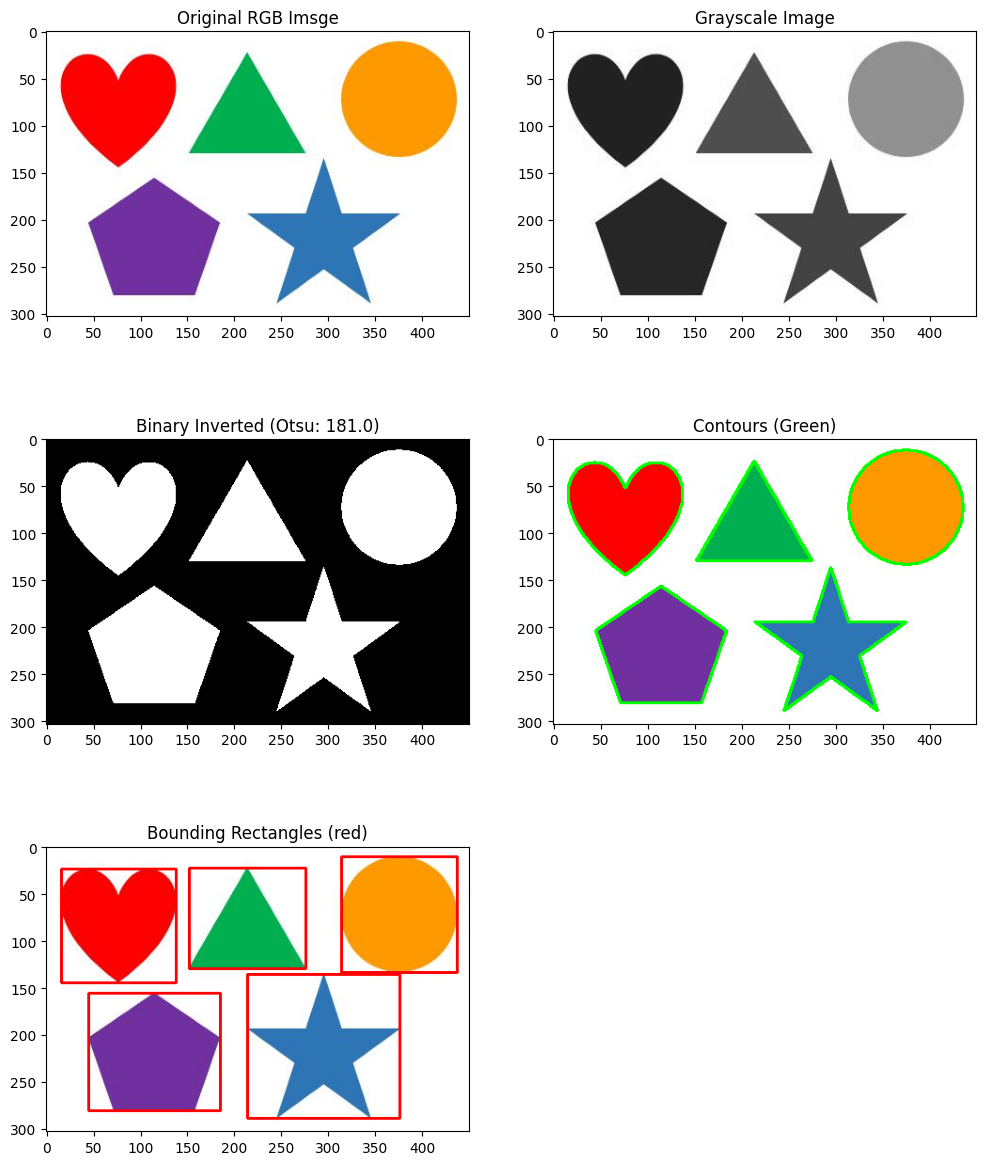

In [ ]:
import imutils

# 1 = BGR | 2 = RGB
path = '/content/drive/MyDrive/2568-term2/image/week 7/'
image_name = 'all_shape.jpg'
image_color = cv2.imread(path + image_name, 1)

if image_color is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_rgb = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# THRESH_BINARY_INV = กลับสี วัตถุเป็นสีขาว background เป็นดำ
# THRESH_OTSU = หาค่า threshold อัตโนมัติ
thresh_val, image_binary_inv = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# image_binary_inv = ภาพขาวดำ
# RETR_EXTERNAL = เอาเฉพาะ contour ด้านนอก
# CHAIN_APPROX_SIMPLE = เก็บจุดขอบเท่าที่จำเป็น
# imutils.grab_contours(cnts) = ดึงเฉพาะ contour ที่แท้จริงออกมา
cnts = cv2.findContours(image_binary_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

# Draw All Contours
# -1 วาดทุก contour, (0, 255, 0) = สีเขียว, 2 = ควาหนาเส้น
image_contours = image_rgb.copy()
cv2.drawContours(image_contours, cnts, -1, (0, 255, 0), 2)

# Draw bounding rectangles
# booundingRect = หากรอบสี่เหลี่ยมที่ครอบ contour ได้มากที่สุด
# (x, y) = มุมซ้าย, w = ความกว้าง, h = ความสูง
img_rect = image_rgb.copy()
for c in cnts:
  (x, y, w, h) = cv2.boundingRect(c)
  cv2.rectangle(img_rect, (x, y), (x + w, y + h), (255, 0, 0), 2)

print(f'Number of objects: {len(cnts)}')

fig = plt.figure(figsize = (12, 15))

plt.subplot(3, 2, 1)
plt.imshow(image_rgb)
plt.title('Original RGB Imsge')

plt.subplot(3, 2, 2)
plt.imshow(image_gray, cmap = 'gray')
plt.title('Grayscale Image')

plt.subplot(3, 2, 3)
plt.imshow(image_binary_inv, cmap = 'gray')
plt.title(f'Binary Inverted (Otsu: {thresh_val})')

plt.subplot(3, 2, 4)
plt.imshow(image_contours)
plt.title('Contours (Green)')

plt.subplot(3, 2, 5)
plt.imshow(img_rect)
plt.title('Bounding Rectangles (red)')

plt.show()

Number of objects is 1


Text(0.5, 1.0, 'Rectangle contours Image')

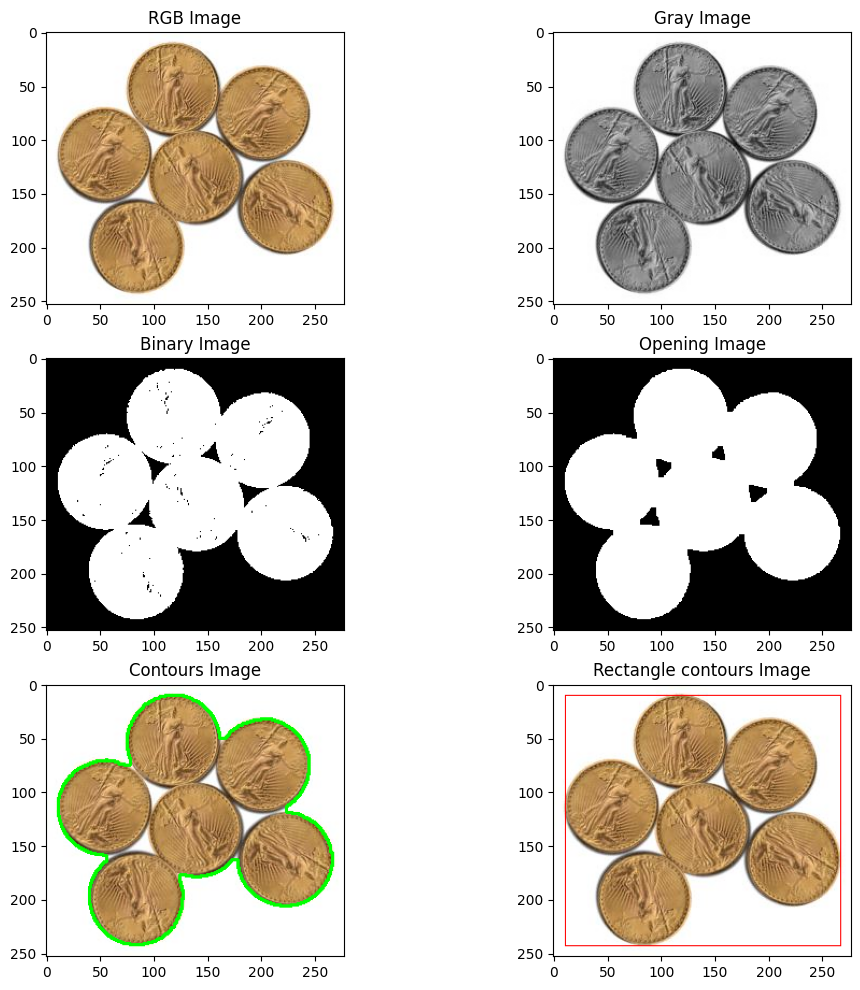

In [ ]:
import imutils

path = '/content/drive/MyDrive/2568-term2/image/week 7/'
image_name = 'coin.jpg'
image_bgr = cv2.imread(path + image_name, 1)

if image_gray is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

ret, thresh = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal
# iterations = 2 ทำซ้ำ 2 รอบ
# RETR_EXTERNAL = เอาเฉพาะขอบนอก, CHAIN_APPROX_SIMPLE = เก็บจุดขอบเท่าที่จำเป็น
# ทำ closing ก่อน findContours เพราะ วัตถุจะแตกออกเป็นหลายชิ้น ขอบเกิน
kernel = np.ones((3, 3), np.uint8)
image_closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations = 2)

contours, hierarchy = cv2.findContours(image_closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# draw contours
image_contours = image_rgb.copy()
cv2.drawContours(image_contours, contours, -1, (0, 255, 0), 2)

image_boxes = image_rgb.copy()
for c in contours:
  x, y, w, h = cv2.boundingRect(c)
  cv2.rectangle(image_boxes, (x, y), (x + w, y + h), (255, 0, 0), 1)

print("Number of objects is", len(contours))

plt.figure(figsize = (12, 12))
plt.subplot(3, 2, 1)
plt.imshow(image_rgb)
plt.title('RGB Image')

plt.subplot(3, 2, 2)
plt.imshow(image_gray, cmap = 'gray')
plt.title('Gray Image')

plt.subplot(3, 2, 3)
plt.imshow(thresh, cmap = 'gray')
plt.title('Binary Image')

plt.subplot(3, 2, 4)
plt.imshow(image_closing, cmap = 'gray')
plt.title('Opening Image')

plt.subplot(3, 2, 5)
plt.imshow(image_contours)
plt.title('Contours Image')

plt.subplot(3, 2, 6)
plt.imshow(image_boxes)
plt.title('Rectangle contours Image')

Found 6 coins


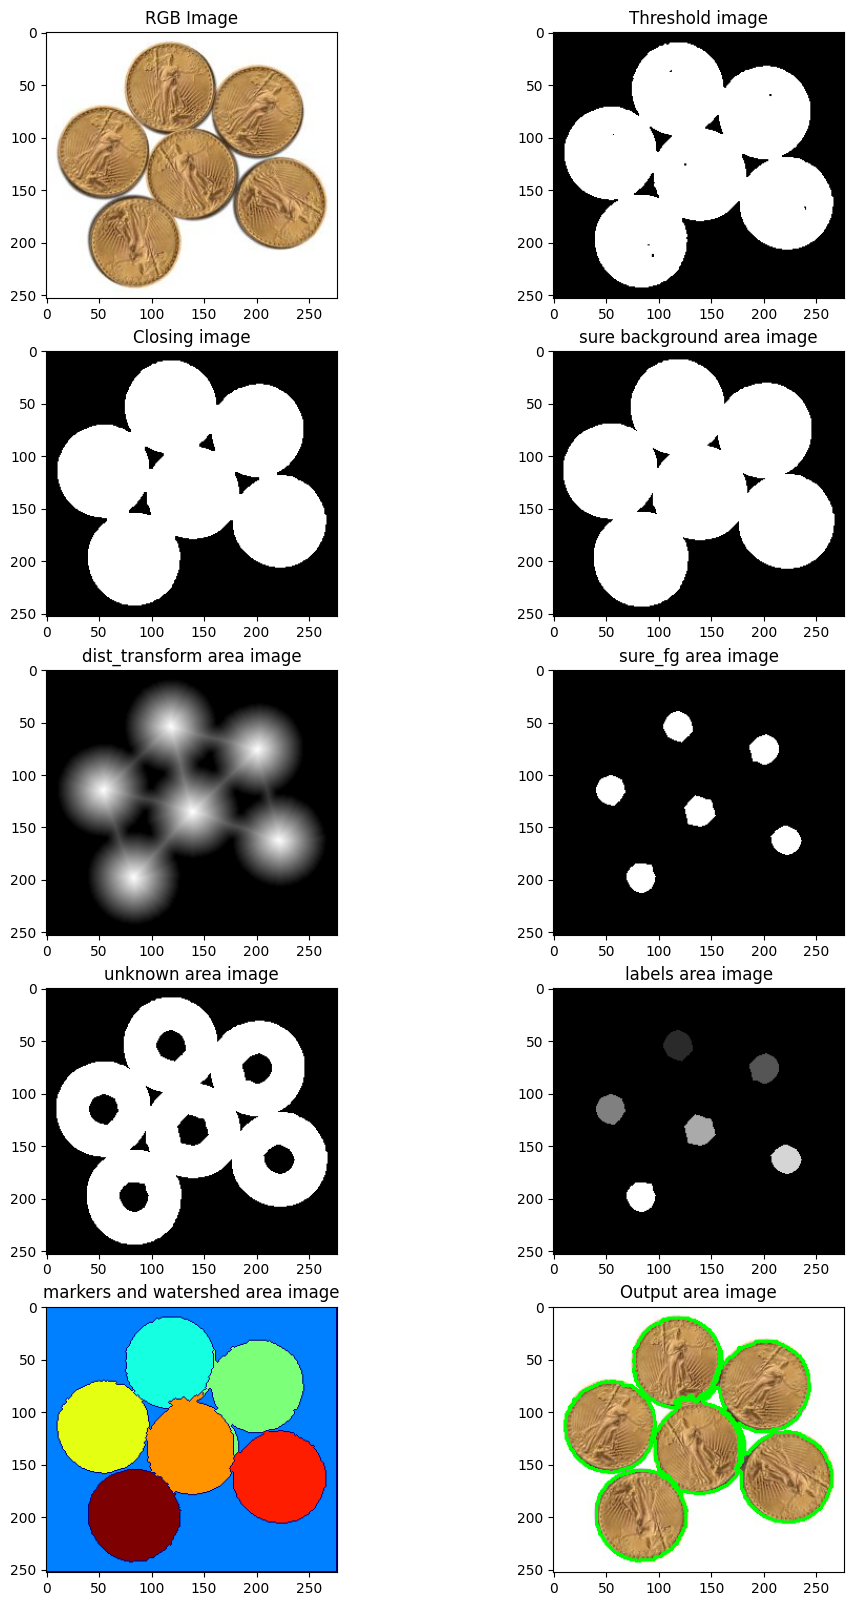

In [ ]:
import imutils

path = '/content/drive/MyDrive/2568-term2/image/week 7/'
image_name = 'coin.jpg'
image_color = cv2.imread(path + image_name, 1)

if image_color is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_rgb = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize = (12, 20))
plt.subplot(5, 2, 1)
plt.imshow(image_rgb)
plt.title('RGB Image')

# blur ภาพ
image_new = image_rgb.copy()
blur = cv2.medianBlur(image_gray, 3)
ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.subplot(5, 2, 2)
plt.imshow(thresh, cmap = 'gray')
plt.title('Threshold image')

# morphologyEx = ปรับรูปทรงของวัตถุในภาพขาว–ดำ
kernel = np.ones((3, 3), np.uint8)
image_closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations = 1)

plt.subplot(5, 2, 3)
plt.imshow(image_closing, cmap = 'gray')
plt.title('Closing image')

# sure background area
# dilate = ขยายภาพได้ใหญ่ขึ้น
kernel = np.ones((3, 3), np.uint8)
sure_bg = cv2.dilate(image_closing, kernel, iterations = 1)

plt.subplot(5, 2, 4)
plt.imshow(sure_bg, cmap = 'gray')
plt.title('sure background area image')

# finding sure foreground area
dist_transform = cv2.distanceTransform(image_closing, cv2.DIST_L2, 5)

plt.subplot(5, 2, 5)
plt.imshow(dist_transform, cmap = 'gray')
plt.title('dist_transform area image')

# Seed region
# .max = ค่าที่สูงที่สุด = จุดศูนย์กลางของวัตถุ
#ถ้า pixel > 0.7*max → 255 (ขาว)
# ถ้า pixel ≤ 0.7*max → 0 (ดำ)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

plt.subplot(5, 2, 6)
plt.imshow(sure_fg, cmap = 'gray')
plt.title('sure_fg area image')

# finging unknow region
# subtract = sure_bg - sure_fg
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

plt.subplot(5, 2, 7)
plt.imshow(unknown, cmap = 'gray')
plt.title('unknown area image')

# Marker labelling
# connectedComponents = แยกก้อนวัตถุ
num_labels, labels = cv2.connectedComponents(sure_fg)

plt.subplot(5, 2, 8)
plt.imshow(labels, cmap = 'gray')
plt.title('labels area image')

# watershed ห้ามใช้ background = 0 เพราะ 0 ถูกจองไว้ให้ unknown
labels = labels + 1
labels[unknown == 255] = 0

# watershed = เพื่อแยกวัตถุที่ติดกันโดยอ้างอิงจาก labels
# jet = show สีคนละสี
labels = cv2.watershed(image_rgb, labels)
plt.subplot(5, 2, 9)
plt.imshow(labels, cmap = 'jet')
plt.title('markers and watershed area image')

# -1 เพราะไม่เอา background
print("Found {} coins". format(num_labels -1))

# label <= 1 = ไม่สนใจ background สนใจแค่วัตถุ
# -1 = วาดทุก contours
for label in np.unique(labels):
  if label <= 1:
    continue

  mask = np.zeros(labels.shape, dtype = np.uint8)
  mask[labels == label] = 255
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cv2.drawContours(image_rgb, contours, -1, (0, 255, 0), 2)

plt.subplot(5, 2, 10)
plt.imshow(image_rgb, cmap = 'gray')
plt.title('Output area image')
plt.show()

Found 6 coins


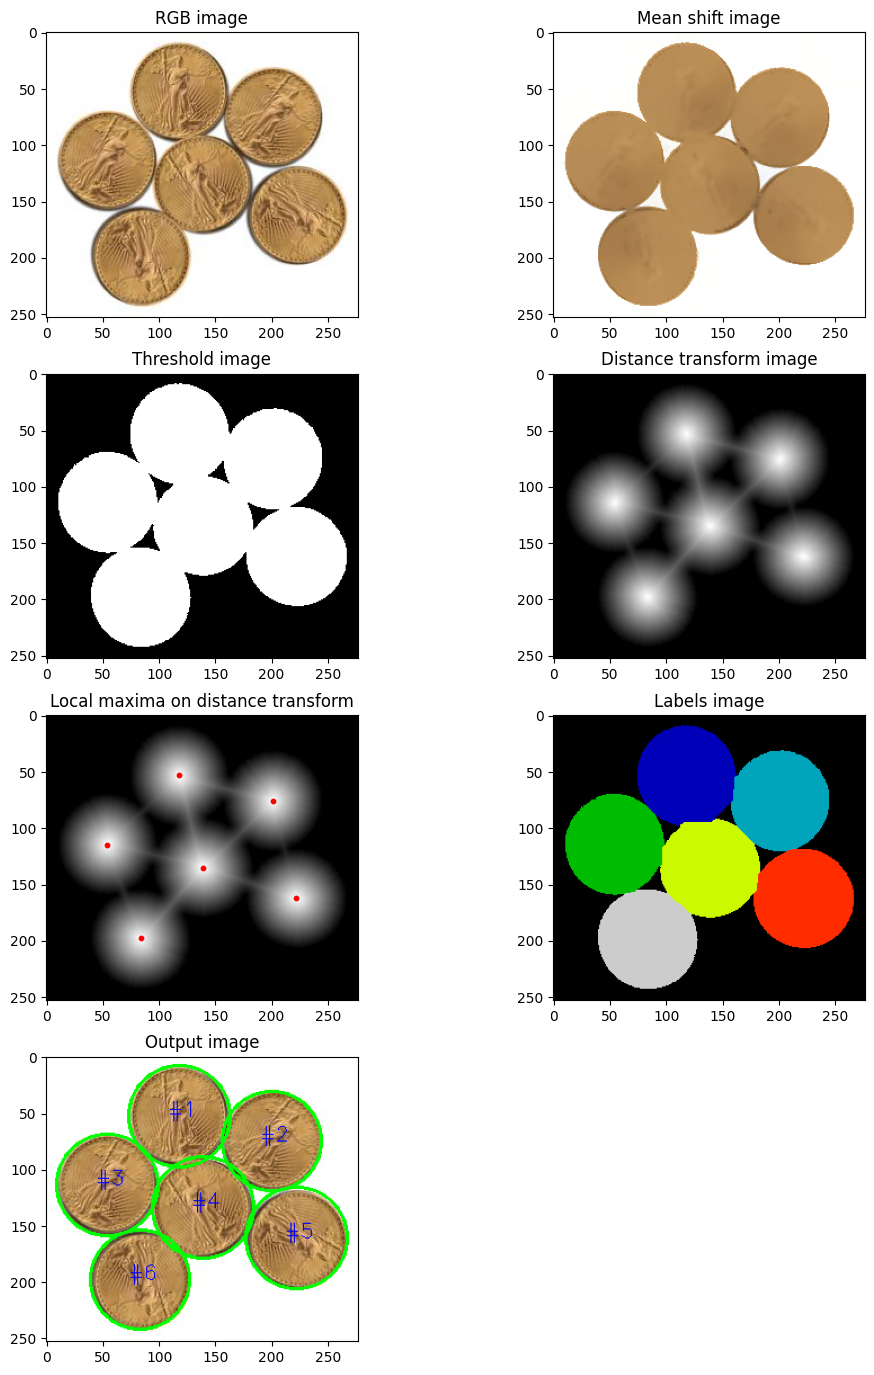

In [ ]:
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import numpy as np
import imutils

image_name = 'coin.jpg'
image_color = cv2.imread(path + image_name, 1)

if image_color is None:
  print(f"image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_rgb = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12, 17))
plt.subplot(4, 2, 1)
plt.imshow(image_rgb)
plt.title('RGB image')

# pyrMeanShiftFiltering = ภาพจะเนียน สีใกล้กันจะถูกรวมเป็นก้อน
shifted = cv2.pyrMeanShiftFiltering(image_color, 21, 51)
plt.subplot(4, 2, 2)
plt.imshow(cv2.cvtColor(shifted, cv2.COLOR_BGR2RGB))
plt.title('Mean shift image')

gray = cv2.cvtColor(shifted, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

plt.subplot(4, 2, 3)
plt.imshow(thresh, cmap = 'gray')
plt.title('Threshold image')

# distance_transform_edt = คือการวัดว่าพิกเซลในวัตถุอยู่ห่างจากขอบมากแค่ไหน
D = ndimage.distance_transform_edt(thresh)
plt.subplot(4, 2, 4)
plt.imshow(D, cmap = 'gray')
plt.title('Distance transform image')

# peak_local_max = จุดกลางของวัตถุแต่ละชิ้น
coords = peak_local_max(D, min_distance = 20)

mask = np.zeros(D.shape, dtype = bool)
mask[tuple(coords.T)] = True
markers, _ = ndimage.label(mask)

# coords[:, 1] = เอาคอลัมน์ที่ 1 ทั้งหมด → ค่า x
# coords[:, 0] = เอาคอลัมน์ที่ 0 ทั้งหมด → ค่า y
# s = ขนาดจุด
plt.subplot(4, 2, 5)
plt.imshow(D, cmap = 'gray')
plt.scatter(coords[:, 1], coords[:, 0], c = 'red', s = 10)
plt.title('Local maxima on distance transform')

# -D = แอ่งน้ำ
# markers = จุดศูนย์กลางของวัตถุแต่ละชิ้น
# mask = (thresh > 0) = ให้ watershed ทำงานเฉพาะบริเวณวัตถุเท่านั้น
# nipy_spectral คือ colormap แบบหลายสีจัดจ้าน
labels = watershed(-D, markers, mask = (thresh > 0))
plt.subplot(4, 2, 6)
plt.imshow(labels, cmap = 'nipy_spectral')
plt.title('Labels image')

print('Found {} coins'.format(len(np.unique(labels)) -1))

# int(r) = รัศมีวงกลม
# (int(x) - 10, int(y)) = ตำแหน่งตัวอักษร | -10 = เลื่อนซ้าย 10 pixel
# cv2.FONT_HERSHEY_SIMPLEX = front
for label in np.unique(labels):
  if label == 0:
    continue

  mask = np.zeros(gray.shape, dtype = "uint8")
  mask[labels == label] = 255

  cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cnts = imutils.grab_contours(cnts)
  c = max(cnts, key = cv2.contourArea)

  ((x, y), r) = cv2.minEnclosingCircle(c)
  cv2.circle(image_rgb, (int(x), int(y)), int(r), (0, 255, 0), 2)
  cv2.putText(image_rgb, '#{}'.format(label), (int(x) - 10, int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 1)

plt.subplot(4, 2, 7)
plt.imshow(image_rgb, cmap = 'gray')
plt.title('Output image')
plt.show()